# 02 – Scaling Study: Does LSA Still Look Like Gradient Descent as the Problem Grows?

In **Notebook 01**, we showed that a one-layer Linear Self-Attention (LSA) model
can learn to imitate a **single step of gradient descent (GD)** on small synthetic
linear regression tasks (with fixed dimension `d` and number of context points `n`).

In this notebook, we **build on that setup** and ask:

> Does the same one-layer LSA architecture continue to behave like gradient descent
> when we scale up the problem (larger input dimension and more in-context examples)?

To answer this, we:
- Reuse the same **LSA architecture**, **gradient descent baseline**, and **task distribution**
  as in Notebook 01.
- Vary the pair `(d, n)` across:
  - (d, n) = (5, 11)
  - (d, n) = (10, 21)
  - (d, n) = (20, 41)
- For each configuration, train a fresh LSA model and compare it to the one-step GD baseline using:
  - Mean squared error (MSE) on the query target.
  - Cosine similarity between LSA and GD predictions.

In [4]:
# Imports and setup (same libraries as in Notebook 01) 
import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

## 1. Shared Setup (Reused from Notebook 01)

We keep the **same core ingredients** as in the base experiment:

- Synthetic linear regression tasks:
  - Each task has a randomly sampled "teacher" weight vector `w*`.
  - We observe a small **context set** of (x, y) pairs.
  - We evaluate on a **query** input `x_q`.
- One-layer **Linear Self-Attention (LSA)** model:
  - Processes context + query tokens in a single forward pass.
  - Predicts the query target from the final query token.
- One-step **gradient descent baseline**:
  - Start from `w = 0`.
  - Take one GD step on the context set.
  - Evaluate at `x_q`.

Below, we re-define the same sampler, model, and helper functions so this
notebook is self-contained.


In [2]:
# 1. Task sampler: synthetic linear regression tasks
class LinearTaskSampler:
    def __init__(self, d, n, batch_tasks, out_dim=1, x_range=1.0, device="cpu"):
        self.d, self.n, self.B = d, n, batch_tasks
        self.out_dim = out_dim
        self.x_range = x_range
        self.device = device

    def sample_batch(self):
        B, d, n = self.B, self.d, self.n
        # teacher weights: [B, out_dim, d]
        W = torch.randn(B, self.out_dim, d, device=self.device)

        # context inputs: [B, n, d]
        X = (2*self.x_range)*torch.rand(B, n, d, device=self.device) - self.x_range

        # context targets: [B, n, out_dim] using batched matmul
        Y = torch.einsum("bnd, bod->bno", X, W)

        # query inputs: [B, d]
        x_q = (2*self.x_range)*torch.rand(B, d, device=self.device) - self.x_range

        # query targets: [B, out_dim]
        y_q = torch.einsum("bd, bod->bo", x_q, W)
        
        return X, Y, x_q, y_q, W

In [5]:
# 2. One-layer Linear Self-Attention model (no softmax)

class LinearSelfAttention1L(nn.Module):
    def __init__(self, token_dim):
        super().__init__()
        D = token_dim
        self.W_Q = nn.Linear(D, D, bias=False)
        self.W_K = nn.Linear(D, D, bias=False)
        self.W_V = nn.Linear(D, D, bias=False)
        self.P   = nn.Linear(D, D, bias=False)

    def forward(self, tokens):
        Q = self.W_Q(tokens)
        K = self.W_K(tokens)
        V = self.W_V(tokens)
        att = torch.einsum("bid,bjd->bij", K, Q)
        val = torch.einsum("bij,bjd->bid", att, V)
        return tokens + self.P(val)


In [7]:
# 3. Helper functions: tokens, readout, and one-step GD baseline
def build_tokens(X, Y, x_q, out_dim=1):
    """
    Build token sequence for LSA model.

    Context tokens: [x_i, y_i] for each context point.
    Query token:    [x_q, 0] with the y-slot initialized to 0.

    Returns:
        tokens: [B, n_context + 1, d + out_dim]
    """
    B, n, d = X.shape
    y_q_init = torch.zeros(B, out_dim, device=X.device)
    ctx = torch.cat([X, Y], dim=-1)
    q = torch.cat([x_q, y_q_init], dim=-1).unsqueeze(1)
    return torch.cat([ctx, q], dim=1)

def readout(updated, out_dim=1):
    """
    Read out the predicted query y from the last token.
    Assumes the y-slot is stored in the last `out_dim` entries.
    """
    return updated[:, -1, -out_dim:]


In [8]:
def gd_one_step(X, Y, x_q, lr):
    """
    Compute a one-step gradient descent prediction for linear regression.

    We start from w_0 = 0 and take one gradient step on the squared loss
    using the context points (X, Y), then evaluate at x_q.
    """
    B, n, d = X.shape
    delta = (lr/n) * (X * Y).sum(dim=1)
    return (delta * x_q).sum(dim=-1, keepdim=True)


## 2. Scaling Configurations and Training Setup

We now fix the **training procedure** to match Notebook 01 as closely as possible:

- Same optimizer: Adam on LSA parameters.
- Same learning rate for LSA: `lsa_lr = 1e-3`.
- Same number of training steps: `num_steps = 2000`.
- Same GD baseline learning rate: `gd_lr = 0.5`.

The only thing we change is the **problem size**, via `(d, n)`:

- (5, 11)
- (10, 21)
- (20, 41)

Larger `d` means higher-dimensional inputs; larger `n` means more in-context examples that the model and baseline must use.


In [9]:
# 4. Scaling configs and training setup

configs = [
    (5,  11),
    (10, 21),
    (20, 41),
]

batch_tasks = 256
num_steps = 2000
gd_lr = 0.5

results = {}

In [10]:
def run_experiment(d, n):
    """
    Train a one-layer LSA model for a given (d, n) configuration and
    compare it to a one-step GD baseline.

    Returns:
        mse_lsa:   MSE of LSA predictions on a fresh batch
        mse_gd:    MSE of GD baseline on the same batch
        cos_sim:   cosine similarity between LSA and GD predictions
        lsa_losses: list of training losses over iterations
    """
    sampler = LinearTaskSampler(d=d, n=n, batch_tasks=batch_tasks, device=device)
    model = LinearSelfAttention1L(token_dim=d+1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    lsa_losses = []
    for step in range(1, num_steps+1):
        X, Y, x_q, y_q, _ = sampler.sample_batch()
        X, Y, x_q, y_q = X.to(device), Y.to(device), x_q.to(device), y_q.to(device)

        tokens = build_tokens(X, Y, x_q)
        out = model(tokens)
        y_lsa = readout(out)

        with torch.no_grad():
            y_gd = gd_one_step(X, Y, x_q, lr=gd_lr)

        loss = F.mse_loss(y_lsa, y_q)
        opt.zero_grad()
        loss.backward()
        opt.step()
        lsa_losses.append(loss.item())

    X, Y, x_q, y_q, _ = sampler.sample_batch()
    X, Y, x_q, y_q = X.to(device), Y.to(device), x_q.to(device), y_q.to(device)
    y_lsa = readout(model(build_tokens(X, Y, x_q)))
    y_gd = gd_one_step(X, Y, x_q, gd_lr)

    mse_lsa = F.mse_loss(y_lsa, y_q).item()
    mse_gd  = F.mse_loss(y_gd,  y_q).item()
    cos_sim = torch.nn.functional.cosine_similarity(y_lsa, y_gd).mean().item()

    return mse_lsa, mse_gd, cos_sim, lsa_losses

In [11]:
# 5. Run experiments for all (d, n) configs

for d, n in configs:
    mse_lsa, mse_gd, cos_sim, losses = run_experiment(d, n)
    results[(d,n)] = {
        "mse_lsa": mse_lsa,
        "mse_gd": mse_gd,
        "cos": cos_sim,
        "final_loss": losses[-1],
    }
    print((d,n), results[(d,n)])

(5, 11) {'mse_lsa': 0.5501484274864197, 'mse_gd': 1.308485984802246, 'cos': 0.9921875, 'final_loss': 0.426196426153183}
(10, 21) {'mse_lsa': 1.0581542253494263, 'mse_gd': 2.4751639366149902, 'cos': 0.953125, 'final_loss': 0.9370170831680298}
(20, 41) {'mse_lsa': 2.4933879375457764, 'mse_gd': 4.380040168762207, 'cos': 0.8828125, 'final_loss': 2.2772607803344727}


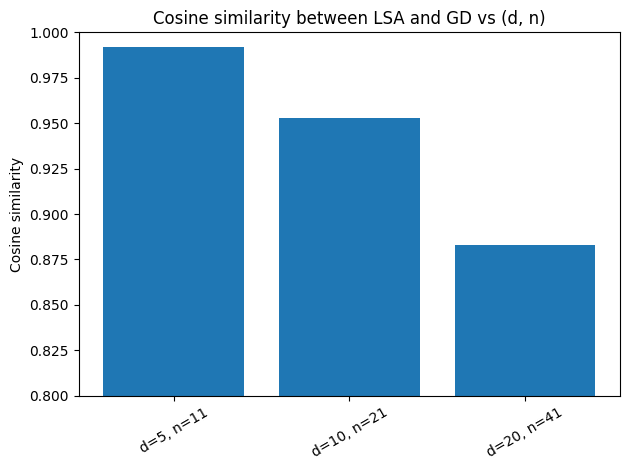

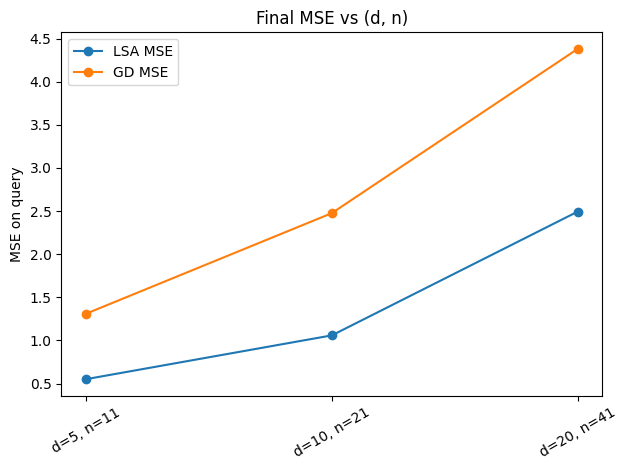

In [12]:
# 6. Visualizations: MSE and cosine similarity vs (d, n)

labels = [f"d={d}, n={n}" for (d, n) in results.keys()]
mse_lsa_vals = [results[k]["mse_lsa"] for k in results]
mse_gd_vals  = [results[k]["mse_gd"]  for k in results]
cos_vals     = [results[k]["cos"]     for k in results]

plt.figure()
plt.bar(labels, cos_vals)
plt.title("Cosine similarity between LSA and GD vs (d, n)")
plt.ylabel("Cosine similarity")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(labels, mse_lsa_vals, marker="o", label="LSA MSE")
plt.plot(labels, mse_gd_vals,  marker="o", label="GD MSE")
plt.title("Final MSE vs (d, n)")
plt.ylabel("MSE on query")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Summary and Discussion

This notebook builds directly on the base experiment from Notebook 01 by keeping
the same model, baseline, and task distribution, and only changing the **problem
size** via `(d, n)`.

**Directional alignment.**  
Across all tested configurations, cosine similarity between LSA and one-step GD
predictions remains high (roughly 0.99 for the smallest setting and about 0.88
for the largest). This suggests that even as the input dimension and number of
context points increase, the LSA model continues to produce updates that are
largely aligned with the gradient descent direction. The fact that alignment
degrades smoothly rather than collapsing indicates a robust but approximate
correspondence.

**Performance vs. baseline.**  
The LSA model consistently achieves lower MSE than the fixed-step one-step GD
baseline. This does not mean that LSA exactly implements gradient descent.
Rather, because it is trained end-to-end to minimize query MSE, LSA can learn
an effective step size or rescaling that adapts to the task distribution. In
that sense, LSA behaves more like a learned, preconditioned one-step optimizer
than a strict GD update.

**Relation to Notebook 01.**  
In Notebook 01, we showed that a one-layer LSA model can match or closely track
one-step GD on small regression tasks. Here we see that this behavior persists
under moderate scaling of problem size: LSA remains strongly GD-like in
direction, while gradually deviating from exact alignment as the tasks become
larger and more complex.

Overall, this scaling study strengthens the view that self-attention layers can
implement approximate optimization procedures in-context, while also highlighting
that this approximation has limits as problem size grows.